#  Adult Income — Model Training & Evaluation
Pipeline: Logistic Regression → Random Forest → XGBoost → LightGBM  
Mỗi model được đánh giá độc lập qua CV → Test → Learning Curve → Confusion Matrix  
Kết luận tổng hợp ở cuối notebook.

---
##  Import & Setup


In [3]:
import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    balanced_accuracy_score, matthews_corrcoef,
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
INPUT_BASE = "/kaggle/input/datasets/khngtrnnh/processed-dataset"
TRAIN_CSV  = os.path.join(INPUT_BASE, "adult_features_train.csv")
TEST_CSV   = os.path.join(INPUT_BASE, "adult_features_test.csv")
MODEL_DIR  = "/kaggle/working/models"
TARGET_COL = "income"

os.makedirs(MODEL_DIR, exist_ok=True)
print("loaded")

loaded


---
## Load Data

In [4]:
train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)

X_train = train.drop(columns=[TARGET_COL])
y_train = train[TARGET_COL].astype(int)

X_test  = test.drop(columns=[TARGET_COL])
y_test  = test[TARGET_COL].astype(int)

print(f"Train: {train.shape}  |  Test: {test.shape}")
print(f"Positive rate (train): {y_train.mean():.3f}")
print(f"Positive rate (test):  {y_test.mean():.3f}")
train.head(3)

Train: (39073, 40)  |  Test: (9769, 40)
Positive rate (train): 0.239
Positive rate (test):  0.239


,age,workclass,education-num,capital-gain,capital-loss,hours-per-week,income,country_income_group,occupation_group,married_flag,...,hours_x_Amer-Indian-Eskimo,hours_x_Asian-Pac-Islander,hours_x_Black,hours_x_Other,hours_x_White,capital_x_Amer-Indian-Eskimo,capital_x_Asian-Pac-Islander,capital_x_Black,capital_x_Other,capital_x_White
0,0.00,0.213293,1.000000,-0.0,-0.000000,-2.0,0,3,0.213139,0,...,-0.0,-0.0,-0.0,-0.0,-2.0,0.0,0.0,0.0,0.0,0.000000
1,0.95,0.548056,-0.666667,-0.0,0.350973,0.0,0,3,0.436034,1,...,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.350973
2,0.80,0.213293,-0.333333,-0.0,-0.000000,-1.0,0,3,0.138603,0,...,-0.0,-0.0,-0.0,-0.0,-1.0,0.0,0.0,0.0,0.0,0.000000


---
## Helper Functions
> CV, Evaluate, Plot — dùng chung cho tất cả model

In [10]:
# ── Cross-Validation ──────────────────────────────────────────────────────────
def cross_validate_model(model, X, y, name):
    cv = StratifiedKFold(5, shuffle=True, random_state=42)
    scores = cross_validate(model, X, y, cv=cv,
                            scoring=["accuracy", "roc_auc", "f1"], n_jobs=-1)
    print(f"  CV Accuracy : {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
    print(f"  CV ROC-AUC  : {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
    print(f"  CV F1       : {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
    return scores

# ── Evaluate on Test Set ───────────────────────────────────────────────────────
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    print(classification_report(y_test, pred))
    return {
        "Accuracy"          : accuracy_score(y_test, pred),
        "Balanced Accuracy" : balanced_accuracy_score(y_test, pred),
        "Precision"         : precision_score(y_test, pred),
        "Recall"            : recall_score(y_test, pred),
        "F1-Score"          : f1_score(y_test, pred),
        "AUC"               : roc_auc_score(y_test, prob),
        "MCC"               : matthews_corrcoef(y_test, pred),
    }

# ── Confusion Matrix ───────────────────────────────────────────────────────────
def plot_confusion(model, X_test, y_test, name):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

# ── Learning Curve ─────────────────────────────────────────────────────────────
def plot_learning_curve(model, X, y, name):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring="f1", n_jobs=-1)
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    gap = train_mean[-1] - val_mean[-1]

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Train F1")
    plt.plot(train_sizes, val_mean,   label="Validation F1")
    plt.title(f"Learning Curve — {name}")
    plt.xlabel("Training size")
    plt.ylabel("F1-Score")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"  Overfitting Gap: {gap:.4f}")
    return gap
print("loaded")



loaded


---
##  Logistic Regression
**Baseline linear model** — L2 regularization, SMOTE, liblinear solver

In [11]:
model_lr = Pipeline([
    ("smote",  SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(
        penalty="l2", C=1, solver="liblinear", max_iter=2000
    ))
])

print("=== Logistic Regression — Cross-Validation (5-fold) ===")
cross_validate_model(model_lr, X_train, y_train, "LR")

=== Logistic Regression — Cross-Validation (5-fold) ===
  CV Accuracy : 0.7941 ± 0.0013
  CV ROC-AUC  : 0.8925 ± 0.0016
  CV F1       : 0.6597 ± 0.0033


{'fit_time': array([2.40229678, 2.22582388, 2.4118607 , 2.45778561, 1.58486056]),
 'score_time': array([0.02579641, 0.02647877, 0.02975678, 0.0243485 , 0.01932311]),
 'test_accuracy': array([0.79334613, 0.79462572, 0.79513756, 0.79178398, 0.79536729]),
 'test_roc_auc': array([0.89369537, 0.89162996, 0.89419055, 0.88987261, 0.89288506]),
 'test_f1': array([0.6592108 , 0.66046118, 0.66087693, 0.65375612, 0.66400504])}

=== Logistic Regression — Fit & Evaluate on Test Set ===
              precision    recall  f1-score   support

           0       0.94      0.78      0.85      7431
           1       0.55      0.83      0.66      2338

    accuracy                           0.79      9769
   macro avg       0.74      0.81      0.76      9769
weighted avg       0.84      0.79      0.81      9769



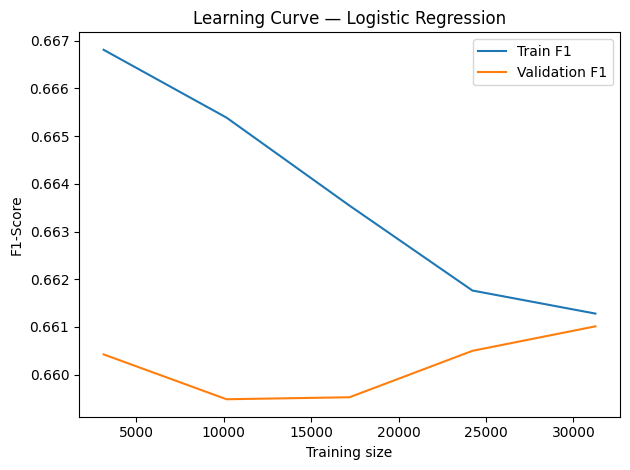

  Overfitting Gap: 0.0003


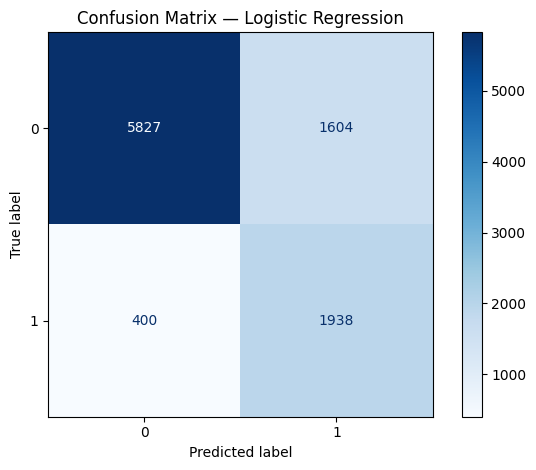

Model saved


In [12]:
print("=== Logistic Regression — Fit & Evaluate on Test Set ===")
model_lr.fit(X_train, y_train)
metrics_lr = evaluate(model_lr, X_test, y_test)
gap_lr = plot_learning_curve(model_lr, X_train, y_train, "Logistic Regression")
plot_confusion(model_lr, X_test, y_test, "Logistic Regression")

metrics_lr["Model"] = "Logistic Regression"
metrics_lr["Overfitting Gap"] = gap_lr

joblib.dump(model_lr, f"{MODEL_DIR}/lr.pkl")
print("Model saved")

---
## Random Forest
**Ensemble bagging model** — 300 trees, max_depth=12, SMOTE

In [13]:
model_rf = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

print("=== Random Forest — Cross-Validation (5-fold) ===")
cross_validate_model(model_rf, X_train, y_train, "RF")

=== Random Forest — Cross-Validation (5-fold) ===
  CV Accuracy : 0.8176 ± 0.0027
  CV ROC-AUC  : 0.9115 ± 0.0015
  CV F1       : 0.6875 ± 0.0031


{'fit_time': array([23.00992632, 23.1845994 , 23.19222975, 23.15480804,  5.40914583]),
 'score_time': array([0.84136367, 0.84108138, 0.84117174, 0.83371258, 0.29602981]),
 'test_accuracy': array([0.81356366, 0.81612284, 0.82111324, 0.81737906, 0.81968262]),
 'test_roc_auc': array([0.91206946, 0.90989075, 0.91361154, 0.9097889 , 0.91208741]),
 'test_f1': array([0.68401648, 0.68617602, 0.6924769 , 0.68533627, 0.68944236])}

=== Random Forest — Fit & Evaluate on Test Set ===
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      7431
           1       0.58      0.84      0.69      2338

    accuracy                           0.82      9769
   macro avg       0.76      0.83      0.78      9769
weighted avg       0.86      0.82      0.83      9769



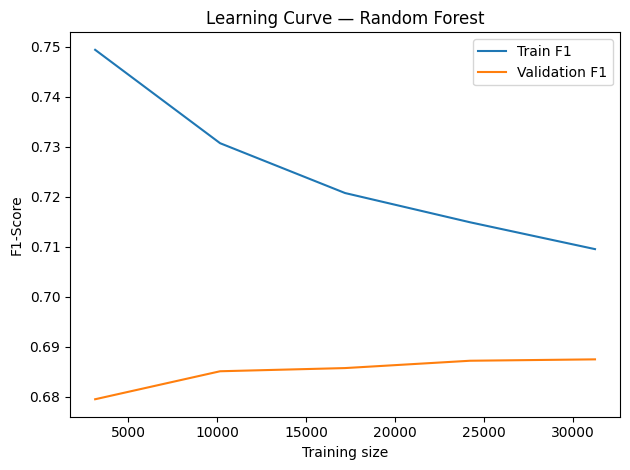

  Overfitting Gap: 0.0220


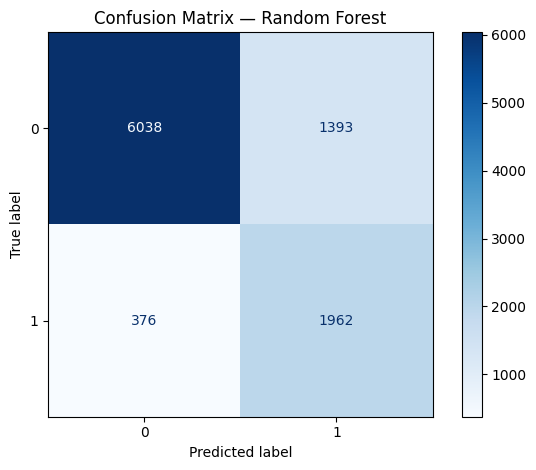

 Model saved


In [14]:
print("=== Random Forest — Fit & Evaluate on Test Set ===")
model_rf.fit(X_train, y_train)
metrics_rf = evaluate(model_rf, X_test, y_test)
gap_rf = plot_learning_curve(model_rf, X_train, y_train, "Random Forest")
plot_confusion(model_rf, X_test, y_test, "Random Forest")

metrics_rf["Model"] = "Random Forest"
metrics_rf["Overfitting Gap"] = gap_rf

joblib.dump(model_rf, f"{MODEL_DIR}/rf.pkl")
print(" Model saved")

---
##  XGBoost
**Gradient boosting (hist)** — 300 estimators, lr=0.05, SMOTE

In [15]:
model_xgb = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

print("=== XGBoost — Cross-Validation (5-fold) ===")
cross_validate_model(model_xgb, X_train, y_train, "XGB")

=== XGBoost — Cross-Validation (5-fold) ===
  CV Accuracy : 0.8471 ± 0.0027
  CV ROC-AUC  : 0.9161 ± 0.0021
  CV F1       : 0.7059 ± 0.0066


{'fit_time': array([4.50734425, 4.49105263, 4.52664781, 4.55944586, 2.68765855]),
 'score_time': array([0.21362972, 0.21472192, 0.21392894, 0.18972754, 0.11594844]),
 'test_accuracy': array([0.84440179, 0.84721689, 0.85131158, 0.84399795, 0.84873304]),
 'test_roc_auc': array([0.91533127, 0.9142528 , 0.91844016, 0.9136743 , 0.9186953 ]),
 'test_f1': array([0.70210681, 0.70706575, 0.71351085, 0.69532617, 0.71142578])}

=== XGBoost — Fit & Evaluate on Test Set ===
              precision    recall  f1-score   support

           0       0.92      0.87      0.90      7431
           1       0.65      0.77      0.71      2338

    accuracy                           0.85      9769
   macro avg       0.79      0.82      0.80      9769
weighted avg       0.86      0.85      0.85      9769



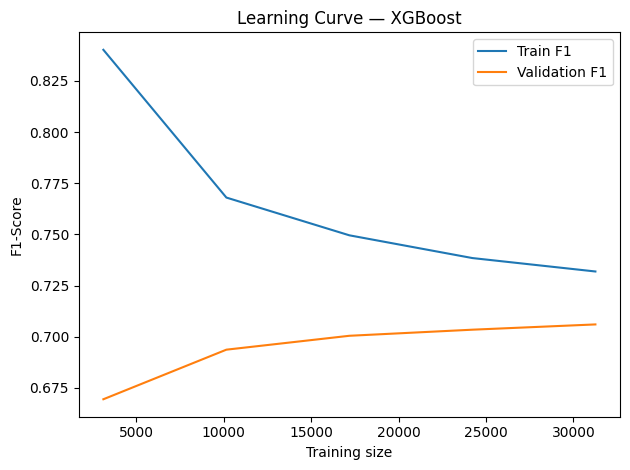

  Overfitting Gap: 0.0259


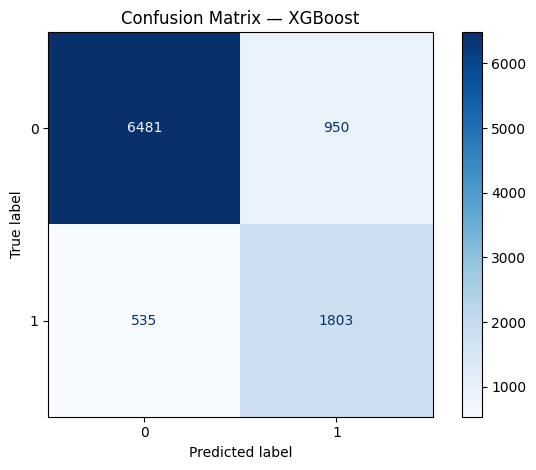

 Model saved


In [16]:
print("=== XGBoost — Fit & Evaluate on Test Set ===")
model_xgb.fit(X_train, y_train)
metrics_xgb = evaluate(model_xgb, X_test, y_test)
gap_xgb = plot_learning_curve(model_xgb, X_train, y_train, "XGBoost")
plot_confusion(model_xgb, X_test, y_test, "XGBoost")

metrics_xgb["Model"] = "XGBoost"
metrics_xgb["Overfitting Gap"] = gap_xgb

joblib.dump(model_xgb, f"{MODEL_DIR}/xgb.pkl")
print(" Model saved")

---
## LightGBM
**Gradient boosting (leaf-wise)** — 300 estimators, num_leaves=63, SMOTE

In [18]:
model_lgbm = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   LGBMClassifier(
        n_estimators=300,
        max_depth=8,
        num_leaves=63,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_gain_to_split=0.01,
        random_state=42,
        verbose=-1
    ))
])

print("=== LightGBM — Cross-Validation (5-fold) ===")
cross_validate_model(model_lgbm, X_train, y_train, "LGBM")

=== LightGBM — Cross-Validation (5-fold) ===
  CV Accuracy : 0.8562 ± 0.0025
  CV ROC-AUC  : 0.9229 ± 0.0016
  CV F1       : 0.7164 ± 0.0056


{'fit_time': array([10.1676836 ,  9.03033328,  7.41419435,  9.4865768 ,  3.60564375]),
 'score_time': array([0.39329004, 0.56717277, 0.61238337, 0.58400464, 0.26503634]),
 'test_accuracy': array([0.85425464, 0.85463852, 0.85924504, 0.85372408, 0.85909905]),
 'test_roc_auc': array([0.92276249, 0.92125347, 0.92510468, 0.92109654, 0.92419305]),
 'test_f1': array([0.71446478, 0.71528822, 0.72194135, 0.70744817, 0.72273986])}

=== LightGBM — Fit & Evaluate on Test Set ===
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      7431
           1       0.68      0.78      0.73      2338

    accuracy                           0.86      9769
   macro avg       0.80      0.83      0.82      9769
weighted avg       0.87      0.86      0.86      9769



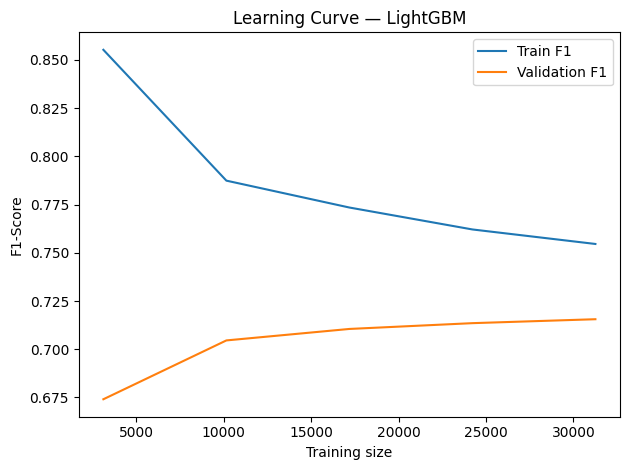

  Overfitting Gap: 0.0390


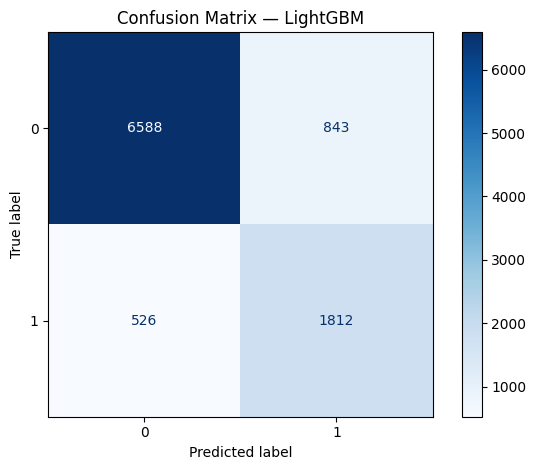

 Model saved


In [19]:
print("=== LightGBM — Fit & Evaluate on Test Set ===")
model_lgbm.fit(X_train, y_train)
metrics_lgbm = evaluate(model_lgbm, X_test, y_test)
gap_lgbm = plot_learning_curve(model_lgbm, X_train, y_train, "LightGBM")
plot_confusion(model_lgbm, X_test, y_test, "LightGBM")

metrics_lgbm["Model"] = "LightGBM"
metrics_lgbm["Overfitting Gap"] = gap_lgbm

joblib.dump(model_lgbm, f"{MODEL_DIR}/lgbm.pkl")
print(" Model saved")

---
##  — Model Comparison
ROC Curve · Precision-Recall Curve · Metric Bar Chart

In [20]:
# ── Tổng hợp metrics ──────────────────────────────────────────────────────────
results_df = pd.DataFrame([metrics_lr, metrics_rf, metrics_xgb, metrics_lgbm])
results_df = results_df.set_index("Model")

print("\n FINAL COMPARISON TABLE ")
print(results_df[[
    "Accuracy", "Balanced Accuracy", "Precision",
    "Recall", "F1-Score", "AUC", "MCC", "Overfitting Gap"
]].sort_values("F1-Score", ascending=False).to_string())


 FINAL COMPARISON TABLE 
                     Accuracy  Balanced Accuracy  Precision    Recall  F1-Score       AUC       MCC  Overfitting Gap
Model                                                                                                               
LightGBM             0.859863           0.830789   0.682486  0.775021  0.725816  0.927754  0.634509         0.039002
XGBoost              0.847989           0.821665   0.654922  0.771172  0.708309  0.920376  0.610142         0.025858
Random Forest        0.818917           0.825860   0.584799  0.839179  0.689268  0.916004  0.585594         0.022032
Logistic Regression  0.794861           0.806531   0.547149  0.828914  0.659184  0.890088  0.544109         0.000267


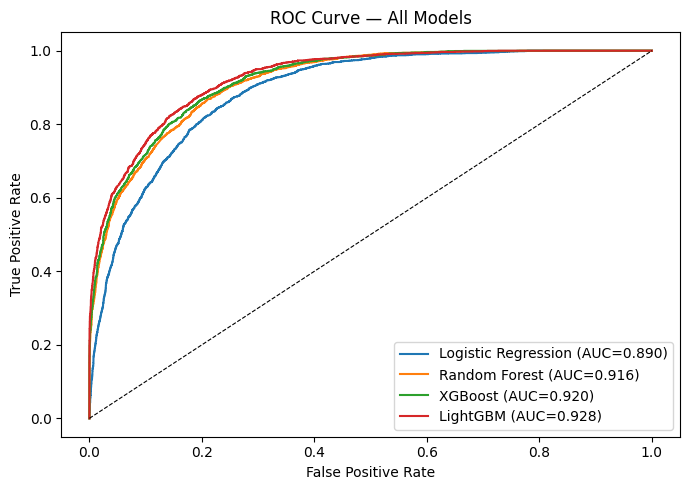

In [21]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
trained = {
    "Logistic Regression": model_lr,
    "Random Forest"      : model_rf,
    "XGBoost"            : model_xgb,
    "LightGBM"           : model_lgbm,
}

plt.figure(figsize=(7, 5))
for name, model in trained.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models")
plt.legend()
plt.tight_layout()
plt.show()

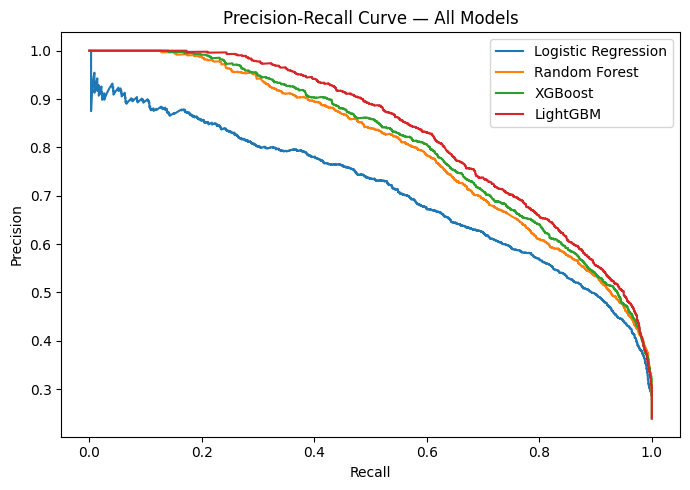

In [22]:
# ── Precision-Recall Curve ────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
for name, model in trained.items():
    prob = model.predict_proba(X_test)[:, 1]
    p, r, _ = precision_recall_curve(y_test, prob)
    plt.plot(r, p, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — All Models")
plt.legend()
plt.tight_layout()
plt.show()

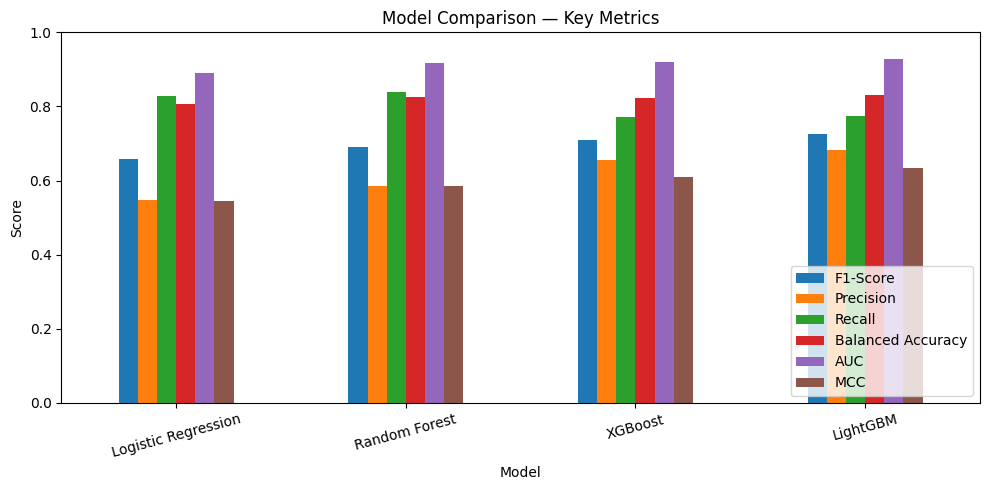

In [23]:
# ── Metric Bar Chart ──────────────────────────────────────────────────────────
plot_cols = ["F1-Score", "Precision", "Recall", "Balanced Accuracy", "AUC", "MCC"]
results_df[plot_cols].plot(kind="bar", figsize=(10, 5), rot=15)
plt.title("Model Comparison — Key Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---


In [26]:

best_f1  = results_df["F1-Score"].idxmax()
best_auc = results_df["AUC"].idxmax()
best_mcc = results_df["MCC"].idxmax()

print("=" * 55)
print("            KẾT LUẬN TỔNG HỢP")
print("=" * 55)
print(f"  Best F1-Score  : {best_f1:<22} ({results_df.loc[best_f1,  'F1-Score']:.4f})")
print(f"  Best AUC       : {best_auc:<22} ({results_df.loc[best_auc, 'AUC']:.4f})")
print(f"  Best MCC       : {best_mcc:<22} ({results_df.loc[best_mcc, 'MCC']:.4f})")
print()

# Overfitting
of_df = results_df["Overfitting Gap"].sort_values()
print("  Overfitting Gap (thấp = ít overfit):")
for m, g in of_df.items():
    tag = " ít overfit nhất" if m == of_df.idxmin() else ""
    print(f"    {m:<22}: {g:.4f}{tag}")
print()


recommend = results_df["F1-Score"].idxmax()
print(f"  {recommend}")
print(f"      ({results_df.loc[recommend, 'F1-Score']:.4f}),",
      f"AUC={results_df.loc[recommend, 'AUC']:.4f},",
      f"MCC={results_df.loc[recommend, 'MCC']:.4f}")
print("=" * 55)

            KẾT LUẬN TỔNG HỢP
  Best F1-Score  : LightGBM               (0.7258)
  Best AUC       : LightGBM               (0.9278)
  Best MCC       : LightGBM               (0.6345)

  Overfitting Gap (thấp = ít overfit):
    Logistic Regression   : 0.0003 ← ít overfit nhất
    Random Forest         : 0.0220
    XGBoost               : 0.0259
    LightGBM              : 0.0390

  LightGBM
      (0.7258), AUC=0.9278, MCC=0.6345
